This notebook is based on the paper by Catherine F. Higham and Desmond J. Higham:

**Deep Learning: An Introduction for Applied Mathematicians.**

*SIAM Review*, Vol. 61, No. 4, pages 860-891, 2019.

In [1]:
using Plots

## 1. sigmoids

The sigmoid function

$$
    y = \frac{1}{1 + e^{-x}}
$$

can be viewed as a smoothed step function.

In [2]:
"""
    function activate(x,W,b)

Evaluates sigmoid function.

    x is the input vector
    y is the output vector

    W contains the weights, b contains the shifts

    If x has s components and y has r components, then
    W is an r by s matrix and b is a vector of length s

    The ith component of y is activate((Wx+b)_i)
    where activate(z) = 1/(1+exp(-z)).

    C F Higham and D J Higham, August 2017
"""
function activate(x,W,b)
    dim = size(W,1)
    y = zeros(dim)
    argexp = -(W*x + b)
    for i=1:dim # y = 1.0 /(1.0 + exp(-(W*x +b)))
        y[i] = 1.0/(1.0 + exp(argexp[i]))
    end
    return y
end

activate

In [3]:
W = zeros(1,1)
W[1,1] = 3.0
y = activate([1.0], W, [-5.0])

1-element Vector{Float64}:
 0.11920292202211755

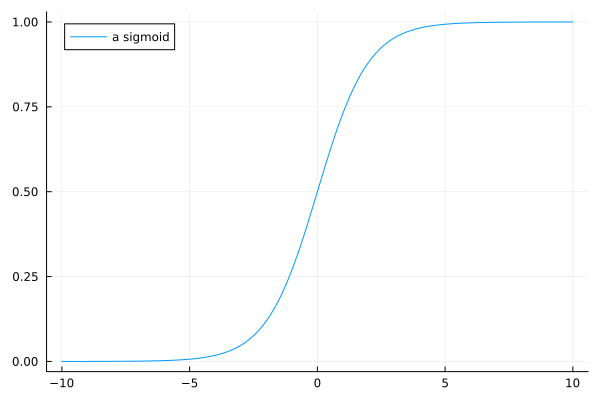

In [4]:
xvals = -10:0.01:10
Wone = zeros(1,1)
Wone[1,1] = 1.0
yvals = [activate([x], Wone, [0.0])[1] for x in xvals]
plot(xvals, yvals, label="a sigmoid",legend=:topleft)

In [5]:
savefig("figsigmoid1.png")

"C:\\Users\\jan\\Courses\\MCS472\\Spring26\\Lec23\\figsigmoid1.png"

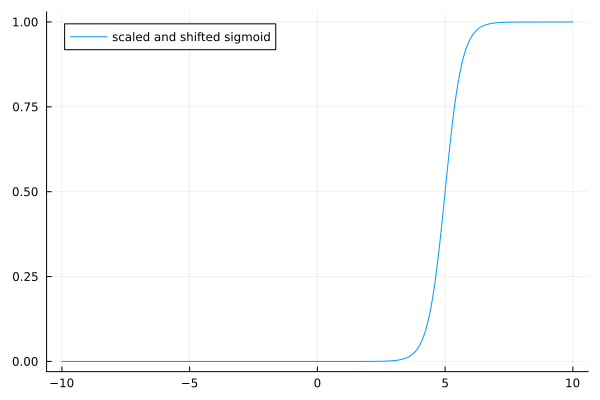

In [6]:
Wthree = zeros(1,1)
Wthree[1,1] = 3.0
yvals = [activate([x], Wthree, [-15.0])[1] for x in xvals]
plot(xvals, yvals, label="scaled and shifted sigmoid",legend=:topleft)

In [7]:
savefig("figsigmoid2.png")

"C:\\Users\\jan\\Courses\\MCS472\\Spring26\\Lec23\\figsigmoid2.png"

## 2. An Artificial Neural Network

In [8]:
x1 = [0.1,0.3,0.1,0.6,0.4,0.6,0.5,0.9,0.4,0.7]

10-element Vector{Float64}:
 0.1
 0.3
 0.1
 0.6
 0.4
 0.6
 0.5
 0.9
 0.4
 0.7

In [9]:
x2 = [0.1,0.4,0.5,0.9,0.2,0.3,0.6,0.2,0.4,0.6]

10-element Vector{Float64}:
 0.1
 0.4
 0.5
 0.9
 0.2
 0.3
 0.6
 0.2
 0.4
 0.6

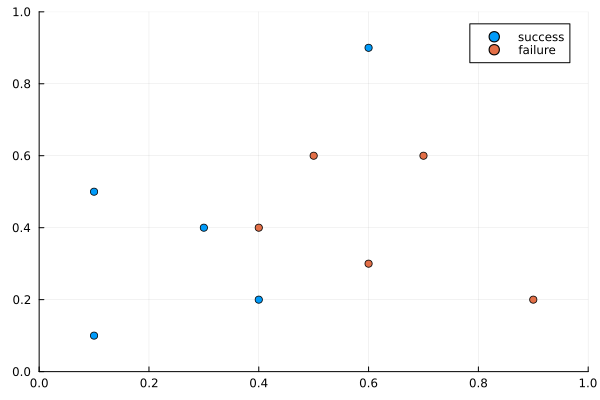

In [10]:
scatter(x1[1:5],x2[1:5], label="success", xlims=[0,1], ylims=[0,1])
scatter!(x1[6:10],x2[6:10], label="failure")

In [11]:
# savefig("figdatalabeled.png")

## 3. Training the Network

We first initialize weights and biases at random.

In [12]:
# rng(5000);
W2 = 0.5*randn(2,2); println("W2 = \n", W2)
W3 = 0.5*randn(3,2); println("W3 = \n", W3)
W4 = 0.5*randn(2,3); println("W4 = \n", W4)
b2 = 0.5*randn(2,1); println("b2 = \n", b2)
b3 = 0.5*randn(3,1); println("b3 = \n", b3)
b4 = 0.5*randn(2,1); println("b4 = \n", b4)

W2 = 
[0.1990221366965653 0.4411863247753275; -0.6183541858022763 0.40881196852668805]
W3 = 
[0.5228460892441968 -0.5528529063772943; 1.0206107426913056 1.2702702863816562; -0.6549831347470759 0.6193570667936791]
W4 = 
[0.3827812551178279 -0.19043288440890419 -0.4496045299809015; 0.35069551642230745 0.29916650474473633 -0.014669630633768846]
b2 = 
[-0.33674260145232254; -0.14975666129136506;;]
b3 = 
[0.17116747646405295; 0.3410112144056227; 0.35864912725747566;;]
b4 = 
[0.10817299150766503; -0.3295217547310434;;]


The labels are defined by ``y``.

In [13]:
y = [ones(1,5) zeros(1,5); zeros(1,5) ones(1,5)]

2×10 Matrix{Float64}:
 1.0  1.0  1.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0  1.0

In the Forward and Back propagate
a training point is picked at random.

In [14]:
eta = 0.05
Niter = 1000000
savecost = zeros(Niter,1)
for counter = 1:Niter
    k = rand((1:10), 1)[1]
    x = [x1[k], x2[k]]
    # Forward pass
    a2 = activate(x,W2,b2)
    a3 = activate(a2,W3,b3)
    a4 = activate(a3,W4,b4)
    # Backward pass
    delta4 = a4.*(ones(length(a4))-a4).*(a4-y[:,k]);
    delta3 = a3.*(ones(length(a3))-a3).*(W4'*delta4);
    delta2 = a2.*(ones(length(a2))-a2).*(W3'*delta3);
    # Gradient step
    W2 = W2 - eta*delta2*x';
    W3 = W3 - eta*delta3*a2';
    W4 = W4 - eta*delta4*a3';
    b2 = b2 - eta*delta2;
    b3 = b3 - eta*delta3;
    b4 = b4 - eta*delta4;
    # Monitor progress
    # newcost = cost(W2,W3,W4,b2,b3,b4)   # display cost to screen
    # savecost(counter) = newcost;
end

In [15]:
function F(x, W2, W3, W4, b2, b3, b4)
    a2 = activate(x, W2, b2)
    a3 = activate(a2, W3, b3)
    a4 = activate(a3, W4, b4)
    return a4
end

F (generic function with 1 method)

In [16]:
z = [x1[1], x2[1]]

2-element Vector{Float64}:
 0.1
 0.1

In [17]:
F(z, W2, W3, W4, b2, b3, b4)

2-element Vector{Float64}:
 0.9997697129335418
 0.00022685084996708138

In [18]:
Z = [[x1[k], x2[k]] for k=1:10]

10-element Vector{Vector{Float64}}:
 [0.1, 0.1]
 [0.3, 0.4]
 [0.1, 0.5]
 [0.6, 0.9]
 [0.4, 0.2]
 [0.6, 0.3]
 [0.5, 0.6]
 [0.9, 0.2]
 [0.4, 0.4]
 [0.7, 0.6]

In [19]:
Y = [F(z, W2, W3, W4, b2, b3, b4) for z in Z]

10-element Vector{Vector{Float64}}:
 [0.9997697129335418, 0.00022685084996708138]
 [0.9904387034659735, 0.009555318339123865]
 [0.9998416832063738, 0.00015991989426036526]
 [0.9941366378907178, 0.005950004762958029]
 [0.9929050523952682, 0.007009118602764661]
 [0.00046544862767281496, 0.9995326713027524]
 [0.00401584707776204, 0.9960147406202137]
 [0.0003125825499247474, 0.9996865253865664]
 [0.012798042121772492, 0.9872013659121587]
 [0.0004170328089283865, 0.9995837221126029]

In [20]:
success = []
failure = []
for i=0:0.01:1
    for j=0:0.01:1
        y = F([i,j], W2, W3, W4, b2, b3, b4)
        if y[1] > y[2]
            push!(success, [i, j])
        else
            push!(failure, [i, j])
        end
    end
end

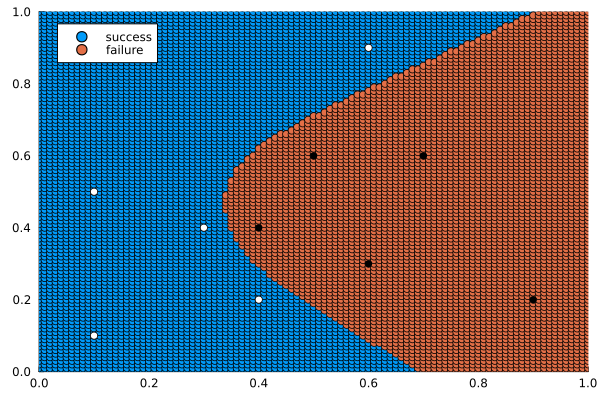

In [21]:
x1f = [z[1] for z in failure]
x2f = [z[2] for z in failure]
x1s = [z[1] for z in success]
x2s = [z[2] for z in success]
scatter(x1s, x2s, label="success", xlims=[0,1], ylims=[0,1], legend=:topleft)
scatter!(x1f, x2f, label="failure")
scatter!(x1[1:5],x2[1:5], label="", xlims=[0,1], ylims=[0,1], color="white")
scatter!(x1[6:10],x2[6:10], label="", color="black")

In [22]:
# savefig("figevaluatedresults.png")